In [19]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [20]:
#Loading and reading the dataset
df = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [21]:
#Keeping only what I need to use
df = df[['subject', 'body', 'tag_1', 'priority', 'language']]

# Keep English only (simplifies NLP)
df = df[df['language'] == 'en']

# Remove missing values
df = df.dropna(subset=['subject', 'body', 'tag_1', 'priority'])

df.head()

,subject,body,tag_1,priority,language
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Account,high,en
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Product,medium,en
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing,low,en
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Product,medium,en
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Feature,high,en


In [22]:
#Combining text
df['text'] = df['subject'] + " " + df['body']

In [23]:
#Cleaning text
def clean_text(text):
  # lowercase
    text = text.lower()
    # remove symbols
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] =  df['text'].apply(clean_text)

In [24]:
# Remove rare categories (less than 20 samples)
counts = df['tag_1'].value_counts()
valid_classes = counts[counts >= 20].index
df = df[df['tag_1'].isin(valid_classes)]

In [25]:
#Converting text to numbers
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])


In [26]:
#Creating 2 targets
# Model 1
y_category = df['tag_1']
# Model 2
y_priority = df['priority']

In [27]:
#Train-test split
X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X, y_category, y_priority,
    test_size=0.2,
    random_state=42
)

In [28]:
#Training the category model
model_category = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_category.fit(X_train, y_cat_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
#Evaluating the category model
cat_predictions = model_category.predict(X_test)

print("Category Accuracy:", accuracy_score(y_cat_test, cat_predictions))
print(classification_report(y_cat_test, cat_predictions, zero_division=0))

Category Accuracy: 0.7767561603530709
               precision    recall  f1-score   support

      Account       0.75      1.00      0.86         9
      Billing       0.98      0.94      0.96       141
          Bug       0.87      0.69      0.77       489
        Crash       0.51      0.90      0.65        42
   Disruption       0.66      0.83      0.74        59
Documentation       0.64      0.77      0.70        69
      Feature       0.77      0.62      0.69       296
     Feedback       0.82      0.69      0.75       355
           HR       0.67      0.80      0.73         5
     Hardware       0.48      0.75      0.59        16
           IT       0.28      0.41      0.33        27
  Integration       0.12      0.50      0.20         2
        Login       1.00      1.00      1.00        21
  Maintenance       0.83      1.00      0.91         5
    Marketing       0.25      0.85      0.39        26
      Network       0.71      0.85      0.78       106
       Outage       0.81  

In [30]:
#Training the priority model
model_priority = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_priority.fit(X_train, y_pri_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
#Evaluating the priority model
pri_predictions = model_priority.predict(X_test)

print("Priority Accuracy:", accuracy_score(y_pri_test, pri_predictions))
print(classification_report(y_pri_test, pri_predictions, zero_division=0))

Priority Accuracy: 0.5148951820522251
              precision    recall  f1-score   support

        high       0.59      0.57      0.58      1068
         low       0.36      0.53      0.43       528
      medium       0.56      0.45      0.50      1123

    accuracy                           0.51      2719
   macro avg       0.50      0.52      0.50      2719
weighted avg       0.53      0.51      0.52      2719



In [32]:
#Testing
sample_text = ["My account is locked and I need urgent help"]

sample_clean = [clean_text(t) for t in sample_text]
sample_vector = vectorizer.transform(sample_clean)

predicted_category = model_category.predict(sample_vector)
predicted_priority = model_priority.predict(sample_vector)

print(f"Predicted Category: {predicted_category[0]}")
print(f"Predicted Priority: {predicted_priority[0]}")

Predicted Category: Account
Predicted Priority: high


In [33]:
# Show sample predictions (comparison)

sample_results = pd.DataFrame({
    'Ticket Text': df.loc[y_cat_test.index]['body'].values[:10],
    'Actual Category': y_cat_test.values[:10],
    'Predicted Category': cat_predictions[:10],
    'Actual Priority': y_pri_test.values[:10],
    'Predicted Priority': pri_predictions[:10]
})

sample_results

,Ticket Text,Actual Category,Predicted Category,Actual Priority,Predicted Priority
0,Drafting a report on the digital strategies em...,Disruption,Disruption,medium,high
1,The SaaS platform has faced sporadic outages,Disruption,Outage,low,medium
2,"Dear customer support, I would like to know th...",Feedback,Feedback,medium,medium
3,The recent malfunction of our data analytics t...,Bug,Bug,high,low
4,We are encountering challenges in boosting our...,Feedback,Feedback,medium,high
5,"Hello, I am seeking comprehensive documentatio...",Documentation,Documentation,high,high
6,Customers are facing periodic login difficulti...,Login,Login,medium,high
7,My subscription renewal was charged twice due ...,Billing,Billing,high,medium
8,An unauthorized access attempt was noted in th...,Security,Security,low,high
9,I am having difficulty integrating ClickUp wit...,Feature,Product,high,low


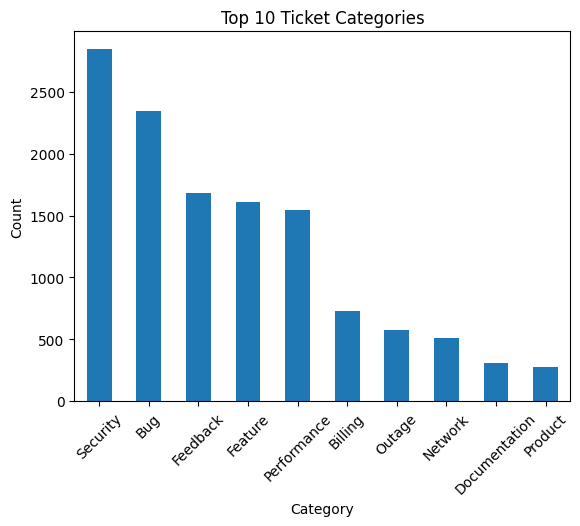

In [34]:
top_categories = df['tag_1'].value_counts().head(10)

top_categories.plot(kind='bar')
plt.title("Top 10 Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

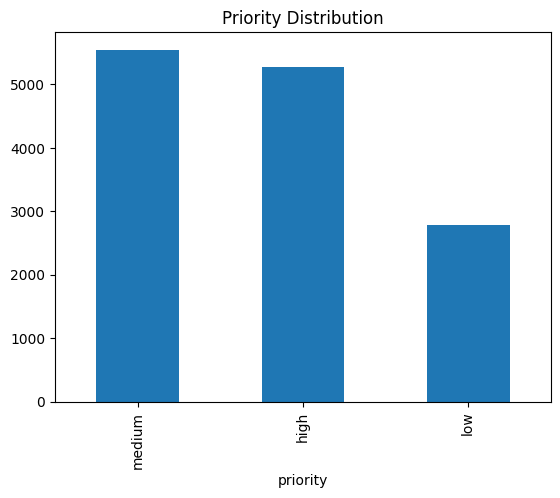

In [35]:
df['priority'].value_counts().plot(kind='bar', title="Priority Distribution")
plt.show()